In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Basic_functions as bf
from scipy.sparse import vstack
import sklearn.utils as sku
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgbm
from lightgbm import early_stopping

In [2]:
raw = open("Speeches\Aaja_Chemnitz'_tale_ved_den_udvidede_spørgetime_med_statsministeren.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\jonas\AppData\Local\Temp\ipykernel_8536\254240665.py:1: SyntaxWarning: invalid escape sequence '\A'
  raw = open("Speeches\Aaja_Chemnitz'_tale_ved_den_udvidede_spørgetime_med_statsministeren.txt", "r", encoding="utf-8").read()


In [3]:
bigons = []
trigons = []
for i in range(len(chars)):
    for j in range(len(chars)):
        bigons.append(chars[i] + chars[j])
for i in range(len(chars)):
    for j in range(len(chars)):
        for k in range(len(chars)):
            trigons.append(chars[i] + chars[j] + chars[k])

In [27]:
raw = open("Speeches/Zenia_Stampes_grundlovstale.txt", "r", encoding="utf-8").read()
text, header = bf.extract_header(raw)
text = text.strip().lower().replace("\n", " ")
header_lines = header.splitlines()

In [22]:
#np.savetxt("words_by_speech.csv", words, delimiter=",", fmt="%s")
#np.savetxt("counts_by_speech.csv", counts, delimiter=",", fmt="%d")
with open("txt_files/words_by_speech.txt", "w", encoding="utf-8") as f:
    for i in range(len(words)):
        for j in range(len(words[i])):
            f.write(words[i][j])
            f.write(", ")
        f.write("\n")
with open("txt_files/counts_by_speech.txt", "w") as f:
    for i in range(len(counts)):
        for j in range(len(counts[i])):
            f.write(str(counts[i][j]))
            f.write(", ")
        f.write("\n")

In [38]:
words = np.genfromtxt("txt_files/words_ranked_years.txt", delimiter=", ", dtype=str)

In [3]:
trigons_filtered = np.genfromtxt("txt_files/trigons_filtered.txt", delimiter="\n", dtype=str)

In [5]:
data_speech, labels_speech = bf.read_files("Speeches", trigons_filtered, sparse=True)
data_article, labels_article = bf.read_files("Articles", trigons_filtered, sparse=True)

In [7]:
data_comb = vstack([data_speech, data_article], format='csr')
labels_comb = np.concatenate([labels_speech, labels_article])
labels_SvsA = np.concatenate([np.ones(len(labels_speech)), np.zeros(len(labels_article))])
data_comb, labels_comb = sku.shuffle(data_comb, labels_SvsA, random_state=42)
data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(data_comb, labels_comb, val_size=0.20, test_size=0.05)

In [ ]:
lgb_train = lgbm.Dataset(data_train.astype("float32"), label=data_train_labels)
lgb_val = lgbm.Dataset(data_val.astype("float32"), label=data_val_labels, reference=lgb_train)
model_binary = lgbm.train(params_binary, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=5000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	val's binary_logloss: 0.154118


AUC Score: 0.9862484456979067


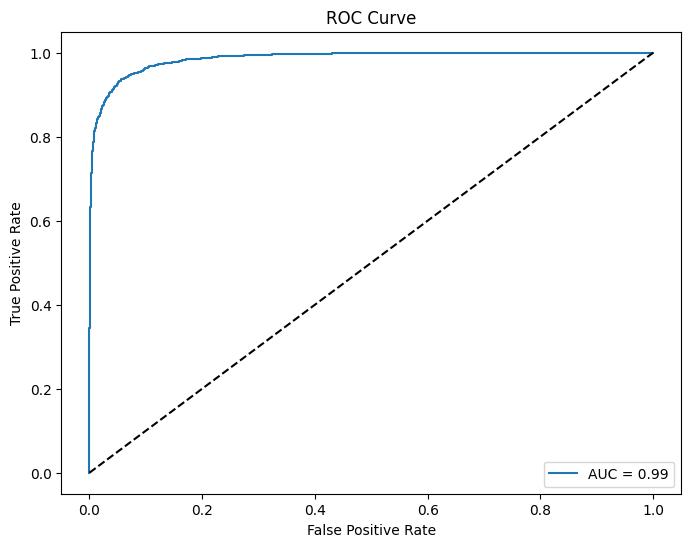

In [22]:
predictions = model_binary.predict(data_test.astype("float32"))
fpr, tpr, _ = roc_curve(data_test_labels, predictions)
auc_score = roc_auc_score(data_test_labels, predictions)
print("AUC Score:", auc_score)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
def data_time_split(data, labels, split_year):
    data_early = data[labels < split_year]
    labels_early = labels[labels < split_year]
    data_late = data[labels >= split_year]
    labels_late = labels[labels >= split_year]
    return data_early, labels_early, data_late, labels_late

In [11]:
data_train, labels_train, data_val, labels_val, data_test, labels_test = train_val_test_split(data_scaled, dates)
data_train_early, labels_train_early, data_train_temp, labels_train_temp = data_time_split(data_train, labels_train, 1800)
data_train_middle, labels_train_middle, data_train_late, labels_train_late = data_time_split(data_train_temp, labels_train_temp, 2000)
data_val_early, labels_val_early, data_val_temp, labels_val_temp = data_time_split(data_val, labels_val, 1800)
data_val_middle, labels_val_middle, data_val_late, labels_val_late = data_time_split(data_val_temp, labels_val_temp, 2000)

In [13]:
params_binary = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}
params_class = {
    "objective": "multiclass",
    "num_class": 3,
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}
params_regression = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "min_data_in_leaf": 5,
    "learning_rate": 0.02,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

In [13]:
labels_train_class = labels_train
labels_train_class[labels_train_class < 1800] = 0
labels_train_class[(labels_train_class >= 1800) & (labels_train_class < 2000)] = 1
labels_train_class[labels_train_class >= 2000] = 2
labels_val_class = labels_val
labels_val_class[labels_val_class < 1800] = 0
labels_val_class[(labels_val_class >= 1800) & (labels_val_class < 2000)] = 1
labels_val_class[labels_val_class >= 2000] = 2

In [18]:
lgb_train = lgbm.Dataset(data_train, label=labels_train_class)
lgb_val = lgbm.Dataset(data_val, label=labels_val_class, reference=lgb_train)
model_multiclass = lgbm.train(params_class, lgb_train, valid_sets=[lgb_val], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[267]	val's multi_logloss: 0.28559


In [19]:
lgb_train_reg1 = lgbm.Dataset(data_train_early, label=labels_train_early)
lgb_val_reg1 = lgbm.Dataset(data_val_early, label=labels_val_early, reference=lgb_train_reg1)
model_regression_early = lgbm.train(params_regression, lgb_train_reg1, valid_sets=[lgb_val_reg1], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[120]	val's l2: 8766.99


In [20]:
lgb_train_reg2 = lgbm.Dataset(data_train_middle, label=labels_train_middle)
lgb_val_reg2 = lgbm.Dataset(data_val_middle, label=labels_val_middle, reference=lgb_train_reg2)
model_regression_middle = lgbm.train(params_regression, lgb_train_reg2, valid_sets=[lgb_val_reg2], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[798]	val's l2: 758.523


In [21]:
lgb_train_reg3 = lgbm.Dataset(data_train_late, label=labels_train_late)
lgb_val_reg3 = lgbm.Dataset(data_val_late, label=labels_val_late, reference=lgb_train_reg3)
model_regression_late = lgbm.train(params_regression, lgb_train_reg3, valid_sets=[lgb_val_reg3], valid_names=["val"], num_boost_round=1000, callbacks=[early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[772]	val's l2: 25.4075


In [25]:
test_pred_multiclass = model_multiclass.predict(data_test, num_iteration=model_multiclass.best_iteration)

In [30]:
test_classified = np.argmax(test_pred_multiclass, axis=1)
test_early = data_test[test_classified == 0]
test_middle = data_test[test_classified == 1]
test_late = data_test[test_classified == 2]
labels_test_early = labels_test[test_classified == 0]
labels_test_middle = labels_test[test_classified == 1]
labels_test_late = labels_test[test_classified == 2]

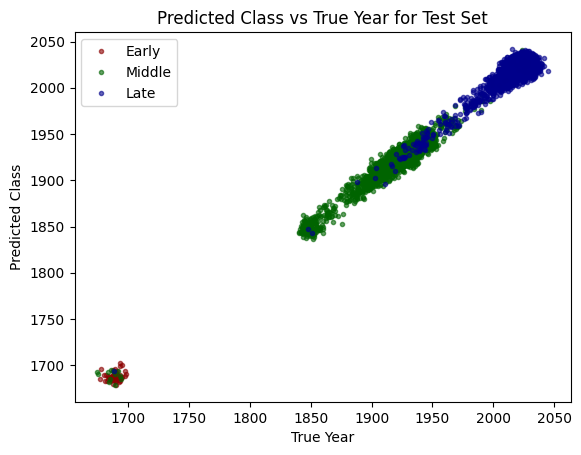

In [55]:
noise_y = np.random.normal(0, 5, size=test_classified.shape)  # Add small noise for better visualization
noise_x = np.random.normal(0, 5, size=test_classified.shape)  # Add small noise for better visualization
plt.plot(labels_test[test_classified == 0] + noise_x[test_classified == 0], labels_test[test_classified == 0] + noise_y[test_classified == 0], ".", label="Early", color="darkred", alpha=0.6)
plt.plot(labels_test[test_classified == 1] + noise_x[test_classified == 1], labels_test[test_classified == 1] + noise_y[test_classified == 1], ".", label="Middle", color="darkgreen", alpha=0.6)
plt.plot(labels_test[test_classified == 2] + noise_x[test_classified == 2], labels_test[test_classified == 2] + noise_y[test_classified == 2], ".", label="Late", color="darkblue", alpha=0.6)
plt.xlabel("True Year")
plt.ylabel("Predicted Class")
plt.title("Predicted Class vs True Year for Test Set")
plt.legend()
plt.show()

In [57]:
test_pred_early = model_regression_early.predict(test_early, num_iteration=model_regression_early.best_iteration)
test_pred_middle = model_regression_middle.predict(test_middle, num_iteration=model_regression_middle.best_iteration)
test_pred_late = model_regression_late.predict(test_late, num_iteration=model_regression_late.best_iteration)
test_pred_combined = np.concatenate((test_pred_early, test_pred_middle, test_pred_late))
labels_test_combined = np.concatenate((labels_test_early, labels_test_middle, labels_test_late))

In [41]:
labels_test_late.min()

np.float64(1688.0)

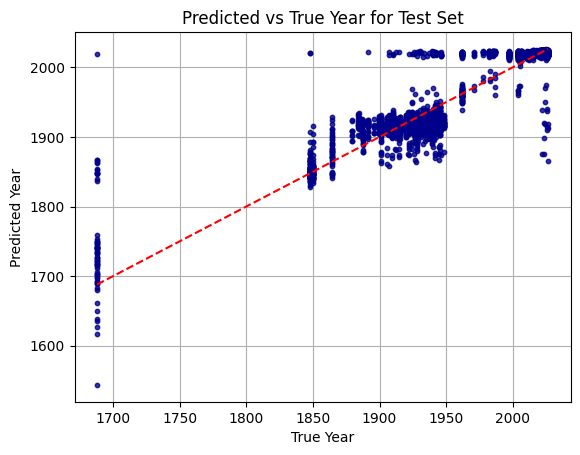

In [66]:
plt.scatter(labels_test_combined, test_pred_combined, alpha=0.8, s=10, color="darkblue", zorder=2)
plt.plot([labels_test_combined.min(), labels_test_combined.max()], [labels_test_combined.min(), labels_test_combined.max()], "r--")
plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title("Predicted vs True Year for Test Set")
plt.grid()
plt.show()

In [69]:
train_data = data_scaled[:int(0.8*len(data_scaled))]
train_labels = labels_scaled[:int(0.8*len(labels_scaled))]
val_data = data_scaled[int(0.8*len(data_scaled)):int(0.95*len(data_scaled))]
val_labels = labels_scaled[int(0.8*len(labels_scaled)):int(0.95*len(labels_scaled))]
test_data = data_scaled[int(0.95*len(data_scaled)):]
test_labels = labels_scaled[int(0.95*len(labels_scaled)):]
lgb_train = lgbm.Dataset(train_data, label=train_labels)
lgb_val = lgbm.Dataset(val_data, label=val_labels, reference=lgb_train)
model = lgbm.train(params, lgb_train, valid_sets=[lgb_train, lgb_val], num_boost_round=1000, callbacks=[early_stopping(50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[764]	training's binary_logloss: 0.0302138	valid_1's binary_logloss: 0.177644


In [70]:
fpr_trigon_filtered, tpr_trigon_filtered, _ = roc_curve(test_labels, model.predict(test_data))

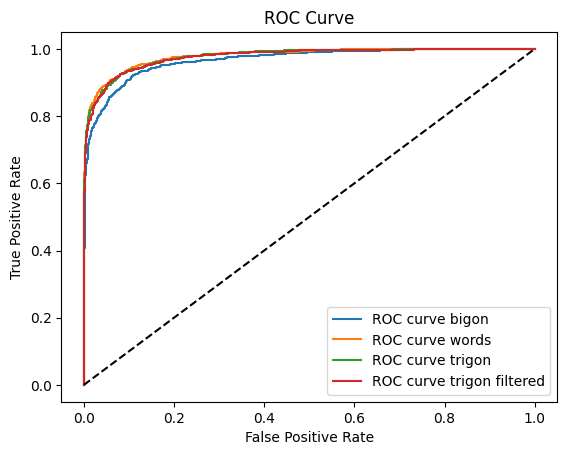

In [71]:
plt.plot(fpr_bigon, tpr_bigon, label="ROC curve bigon")
plt.plot(fpr_words, tpr_words, label="ROC curve words")
plt.plot(fpr_trigon, tpr_trigon, label="ROC curve trigon")
plt.plot(fpr_trigon_filtered, tpr_trigon_filtered, label="ROC curve trigon filtered")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

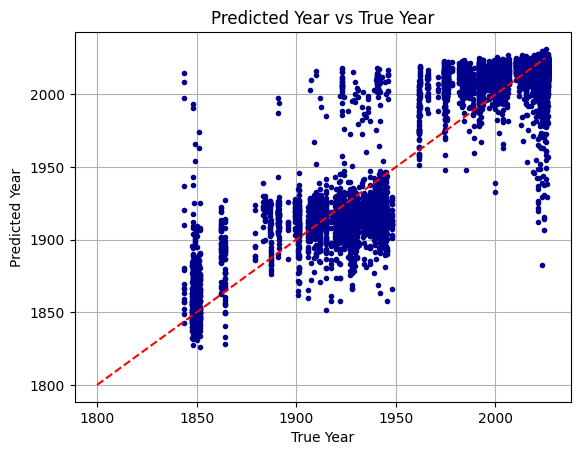

In [12]:
plt.plot(test_labels, model.predict(test_data), ".", color="darkblue")
plt.plot(val_labels, model.predict(val_data), ".", color="darkblue")
plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title("Predicted Year vs True Year")
plt.plot([1800, 2025], [1800, 2025], "r--")
plt.grid()

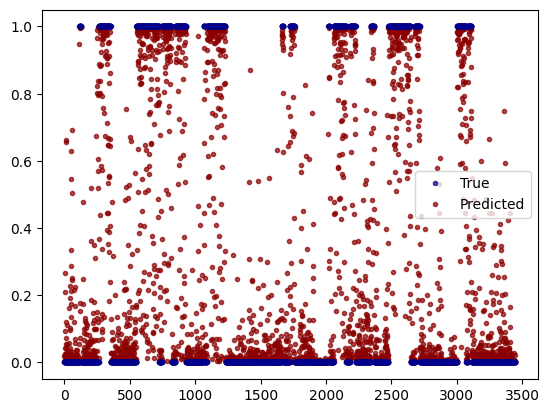

In [25]:
plt.plot(test_labels, '.', label="True", alpha=0.7, color="darkblue", zorder=3)
plt.plot(model.predict(test_data), '.', label="Predicted", alpha=0.7, color="darkred")
plt.legend()
plt.show()

In [16]:
idx = np.argsort(model.feature_importance(importance_type="gain"))[::-1]
print(np.array(bigons)[idx][:50])

['aa' 'å ' 'de' 'a ' 'øi' 'år' 'kj' 'ei' 'ee' 'qa' 'r ' 'ae' 'ej' 'gj'
 'e ' 'jø' 'kv' ' p' 'gø' 'ig' 'jo' 'ii' 'nd' 'lk' 's ' 'på' 'hr' 'do'
 'øj' ' h' 'ls' 'hi' 'i ' 'th' 'er' 'gu' ' d' 'hv' 'ju' ' a' 'ar' 'en'
 't ' 'in' 'vj' 'iø' 'et' 'el' 'rr' ' g']


In [ ]:
#np.savetxt("txt_files/words_ranked_years.txt", words[idx], delimiter="\n", fmt="%s")

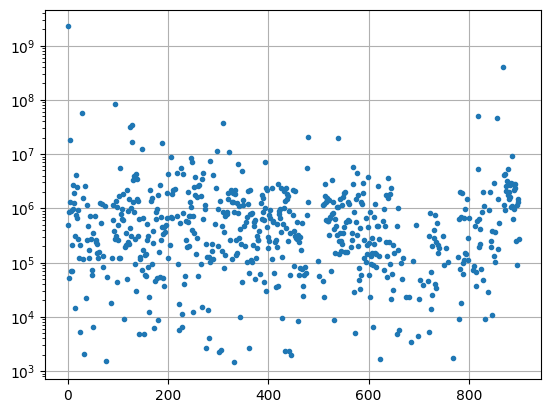

In [17]:
plt.plot(model.feature_importance(importance_type="gain"), ".")
plt.yscale("log")
plt.grid()

In [6]:
test_speech = open("test.txt", "r").read()
test_speech_data = bf.convert_to_data(test_speech, chars)

In [7]:
model.predict([test_speech_data])

array([23.64302537])

In [27]:
np.mean(labels)

np.float64(1993.833620919064)

In [13]:
model.predict(test_data)

array([ -43.45949295,  -55.31170448,  -41.86957323,  -61.60097825,
        -32.50387642,   15.8978201 ,   26.50305802,   10.3817101 ,
         23.54973952,  -75.1508267 ,   25.89405299,   24.26719992,
         19.27546165,   21.88278845,   18.91638827,   23.53752988,
         31.7233499 ,   15.75853587, -122.08753968,   23.71300754,
         18.44896129,   23.31839616,   16.0102125 ,   21.19210292,
          5.51567146,   21.60828215,   25.42972843,   25.01657786,
         26.29343679,   23.92454995,   26.18655454,   23.69506529,
         10.65264355,   24.38383314,   10.64566627,   23.69690549,
         23.34904098,   16.09072231,   22.8684581 ,   23.79729154,
         20.85383015,   24.04316806,   24.12764137,   23.89440954,
         16.31669968,   10.35891703,   20.33592943,   19.16334952,
         20.64140921,   24.11454124,   28.26948276,   25.23077268,
         26.1321853 ,   24.29464827,   17.40945138,   18.31327158,
          7.73357783,   16.13740252,   18.38265718,   15.15270

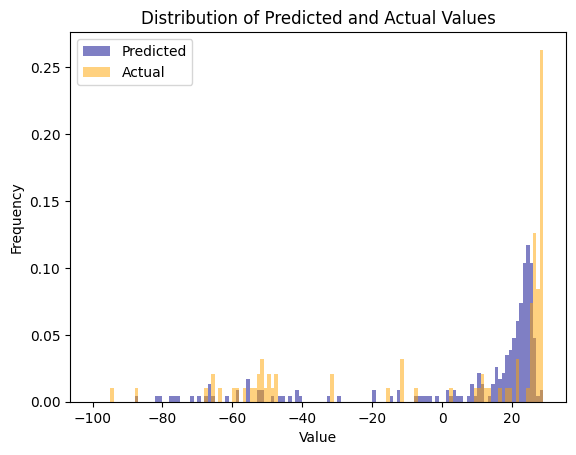

In [25]:
plt.hist(model.predict(test_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(test_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()

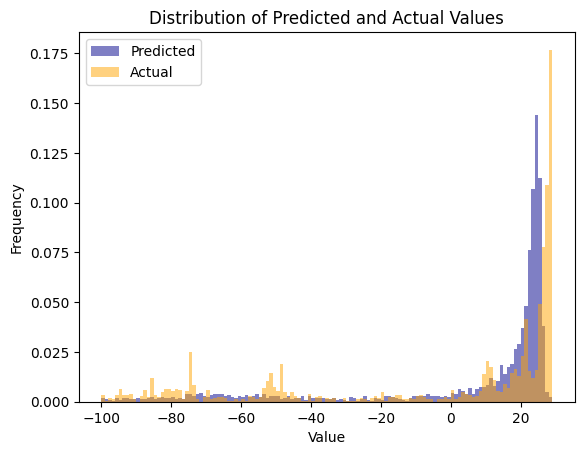

In [26]:
plt.hist(model.predict(train_data), bins=np.arange(-100, 30, 1), label="Predicted", color="darkblue", alpha=0.5, density=True)
plt.hist(train_labels, bins=np.arange(-100, 30, 1), label="Actual", color="orange", alpha=0.5, density=True)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted and Actual Values")
plt.legend()
plt.show()